In [376]:
!pip install imbalanced-learn==0.6.0
!pip install scikit-learn==0.22.1

  Using cached scikit-learn-0.22.1.tar.gz (6.9 MB)
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for scikit-learn
  Running setup.py clean for scikit-learn
Failed to build scikit-learn
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (scikit-learn)


In [377]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix,ConfusionMatrixDisplay, precision_recall_fscore_support, precision_score, recall_score
from scipy import stats
from sklearn.impute import KNNImputer
from scipy.stats import boxcox
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.tree import export_graphviz
from sklearn.metrics import roc_auc_score, precision_recall_curve, roc_curve, auc
import graphviz
from sklearn.model_selection import GridSearchCV

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/titanic/titanic.csv


In [378]:
#data = pd.read_csv(r"/kaggle/input/food-items/food_items.csv")
data = pd.read_csv(r"/kaggle/input/titanic/titanic.csv")
data.head()
#1- This is a binary classification problem to predict who survived the titanic based on some features of these people

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [379]:
data.duplicated().sum() #no duplicates

0

In [380]:
data.isnull().sum().sum() #checking for missing values

866

In [381]:
imputer = KNNImputer(n_neighbors=5) #5 neighbours
data[['Age']] = pd.DataFrame(imputer.fit_transform(data[['Age']]))
data = data.drop(columns="Cabin") #dropped because most of it is missing
data['Embarked'] = data["Embarked"].fillna(data["Embarked"].mode()[0])
data.isnull().sum().sum()# filled missing values

0

In [382]:
data = data.drop(columns=["PassengerId", "Name", "Ticket"]) # useless
data.head(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


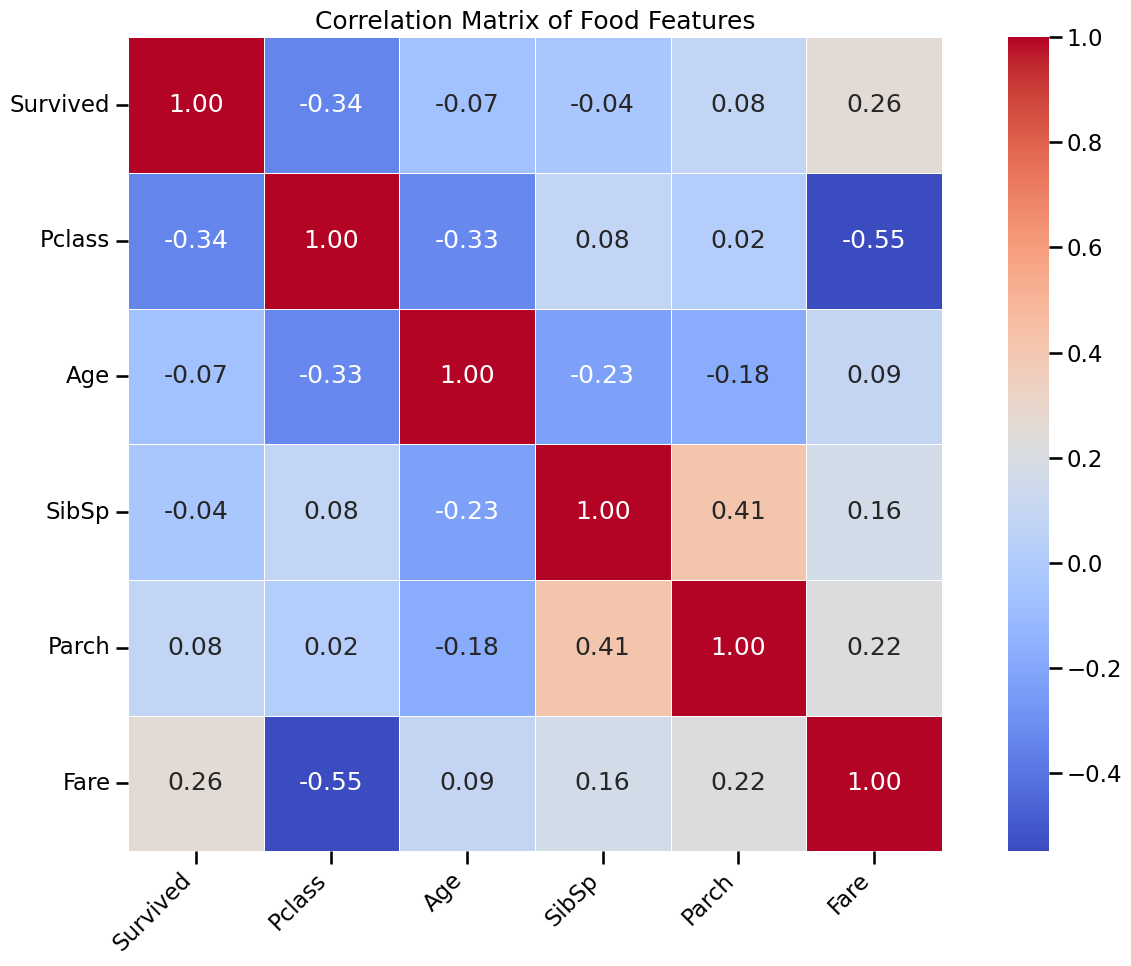

In [383]:
# Correlation Matrix
numeric_df = data.drop(columns=['Sex', 'Embarked']) # no correlations

corr_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title("Correlation Matrix of Food Features")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


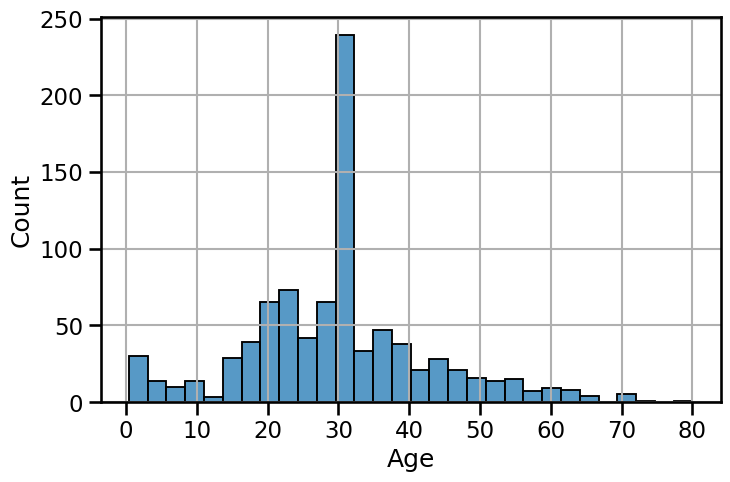

In [384]:
#Histogram plots to spot skewness
plt.figure(figsize=(8, 5))
sns.histplot(x=numeric_df["Age"])
plt.grid(True)
plt.show() # skewness

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


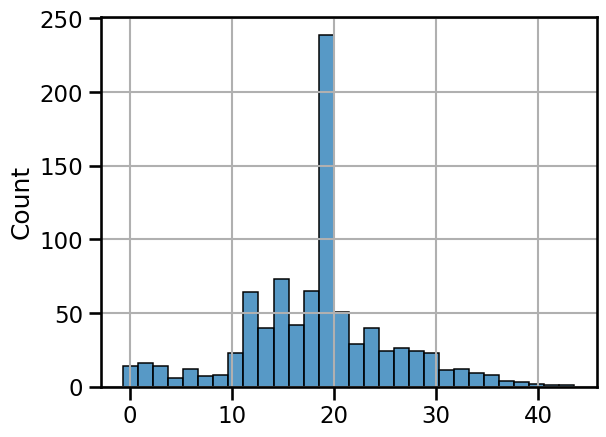

In [385]:
newAgeArr = boxcox(data["Age"])
newAge = newAgeArr[0]
sns.histplot(newAge) # more normal
plt.grid(True)
plt.show() #no skewness
data["Age"] = newAge

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


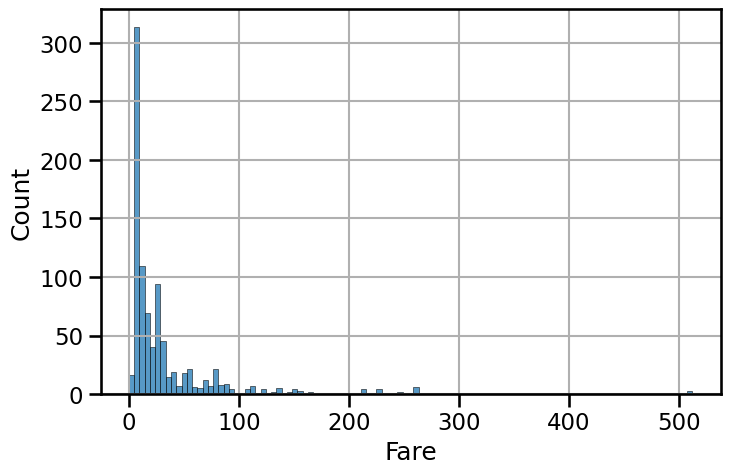

In [386]:
plt.figure(figsize=(8, 5))
sns.histplot(x=numeric_df["Fare"])
plt.grid(True)
plt.show() # skewness

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


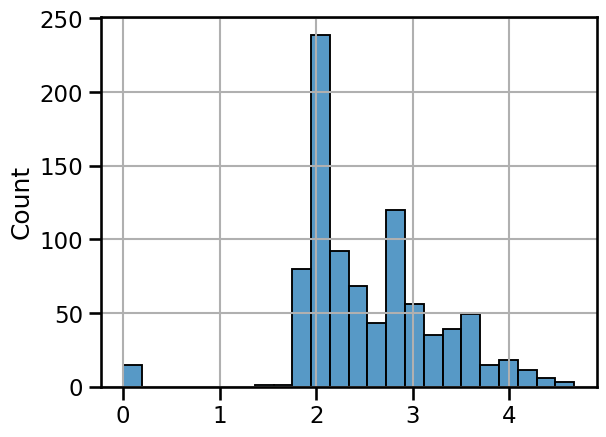

In [387]:
newFareArr = boxcox(data["Fare"] + 1)
newFare = newFareArr[0]
sns.histplot(newFare) # more normal
plt.grid(True)
plt.show() #no skewness
data["Fare"] = newFare

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


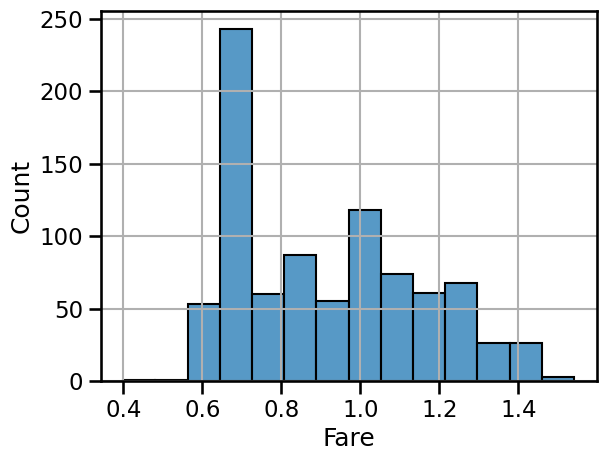

In [388]:
data["Fare"] = np.log(data["Fare"])
sns.histplot(data["Fare"])
plt.grid(True)
plt.show()

In [389]:
data = pd.get_dummies(data, columns=['Embarked', 'Sex'], drop_first=True).astype(float)
data.head(5)

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Sex_male
0,0.0,3.0,14.251664,1.0,0.0,0.645387,0.0,1.0,1.0
1,1.0,1.0,23.036653,1.0,0.0,1.252088,0.0,0.0,0.0
2,1.0,3.0,16.531180,0.0,0.0,0.678266,0.0,1.0,0.0
3,1.0,1.0,21.449596,1.0,0.0,1.195212,0.0,1.0,0.0
4,0.0,3.0,21.449596,0.0,0.0,0.683945,0.0,1.0,1.0


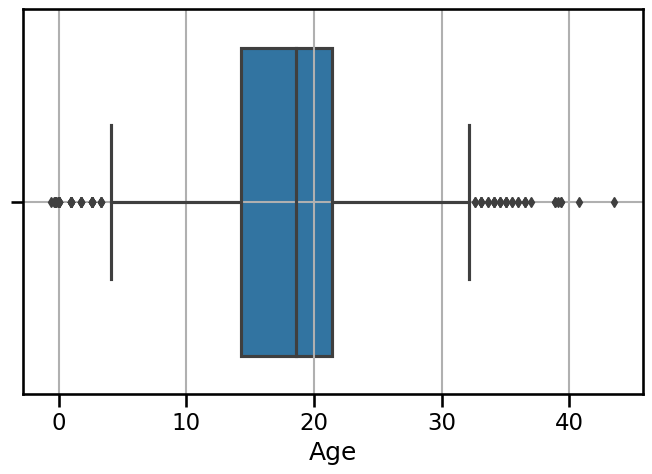

In [390]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=data['Age'])
plt.xlabel('Age')
plt.grid(True)
plt.show() #outliers

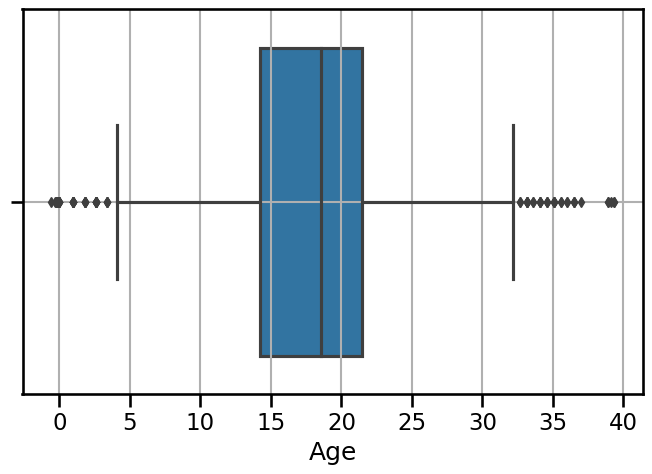

In [391]:
z_scores = stats.zscore(data["Age"]) #getting outliers
outliers_z = data[(np.abs(z_scores) > 3)]  # Threshold at 3 
data = data.drop(outliers_z.index) #cleaning them
plt.figure(figsize=(8, 5))
sns.boxplot(x=data['Age'])
plt.xlabel('Age')
plt.grid(True)
plt.show() #removed some

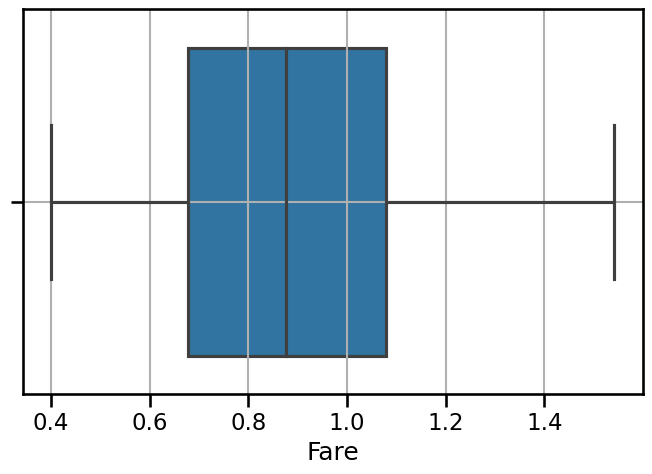

In [392]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=data['Fare'])
plt.xlabel('Fare')
plt.grid(True)
plt.show() #Perfect

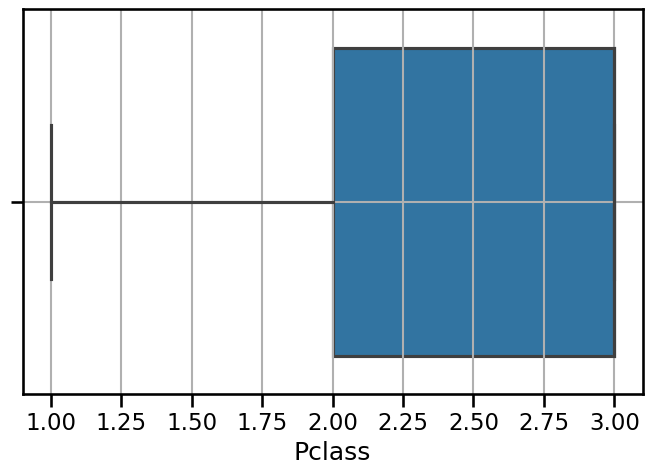

In [393]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=data['Pclass'])
plt.xlabel('Pclass')
plt.grid(True)
plt.show() #perfect

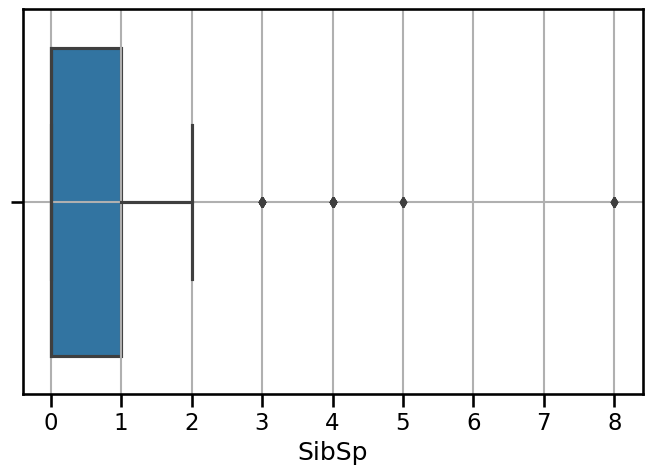

In [394]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=data['SibSp'])
plt.xlabel('SibSp')
plt.grid(True)
plt.show() #outliers

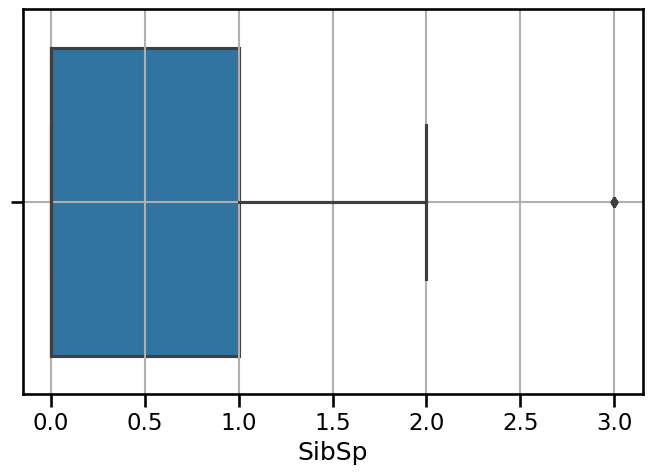

In [395]:
z_scores = stats.zscore(data["SibSp"]) #getting outliers
outliers_z = data[(np.abs(z_scores) > 3)]  # Threshold at 3 
data = data.drop(outliers_z.index) #cleaning them
plt.figure(figsize=(8, 5))
sns.boxplot(x=data['SibSp'])
plt.xlabel('SibSp')
plt.grid(True)
plt.show() #removed some

In [396]:
print(np.isinf(data).sum())  # count of infinity values
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.fillna(data.median(), inplace=True) 

Survived       0
Pclass         0
Age            0
SibSp          0
Parch          0
Fare          15
Embarked_Q     0
Embarked_S     0
Sex_male       0
dtype: int64


<Axes: xlabel='Survived'>

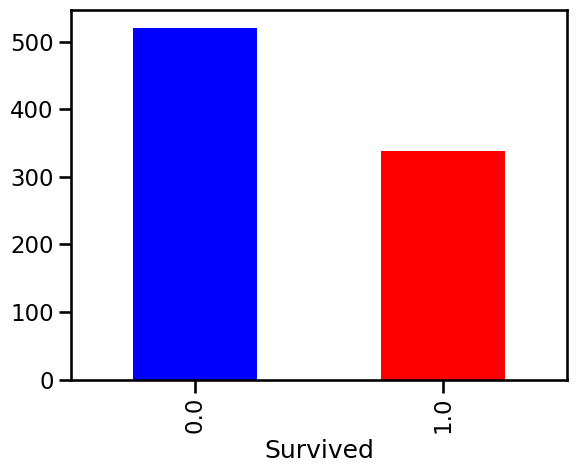

In [397]:
x_df = data.drop(columns='Survived')
y_df = data["Survived"]
y_df.value_counts().plot.bar(color=['blue', 'red'])

In [398]:
X_train, X_test, y_train, y_test = train_test_split(x_df, y_df, test_size = 0.2, random_state=41, stratify=y_df)

In [399]:
# #Fixing imbalanced data using SMOTE
# sm = SMOTE(random_state = 2)
# X_train, y_train = sm.fit_resample(X_train, y_train.values.ravel())
# X_train.shape #data increased
# pd.Series(y_train).value_counts(normalize=True).plot.bar(color=[ 'blue', 'red'])
# #class imbalance fixed

In [400]:
log_transformer = FunctionTransformer(np.log1p, validate=True)

pipeline = Pipeline([
    ('log', log_transformer),
    ('scaler', StandardScaler())
])

X_train_scaled = pipeline.fit_transform(X_train)

# transforming X_test
X_test_scaled = pipeline.transform(X_test)

In [401]:
model_log = LogisticRegression(class_weight='balanced', random_state=42)
model_log.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

DTC = DecisionTreeClassifier(random_state=42, class_weight='balanced')   
DTC.fit(X_train_scaled, y_train)
y_pred_desc = DTC.predict(X_test_scaled)

RFTC = RandomForestClassifier(n_estimators=100, random_state=42)
RFTC.fit(X_train_scaled, y_train)
y_pred_rf = RFTC.predict(X_test_scaled)

xgbc = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric="logloss")
xgbc.fit(X_train_scaled, y_train)
y_pred_xgb = xgbc.predict(X_test_scaled)

In [402]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
lst_accu_stratified = []


In [403]:
def evaluate_metrics():
    results = []
    models = {
        "Normal Logistic": model_log,
        "Decision tree": DTC,
        "Random Forest": RFTC,
        "XGBoost": xgbc,
    }
    
    for name, model in models.items():
        for train_idx, test_idx in skf.split(x_df, y_df):
            X_train_fold, X_test_fold = x_df.iloc[train_idx], x_df.iloc[test_idx]
            y_train_fold, y_test_fold = y_df.iloc[train_idx].values.ravel(), y_df.iloc[test_idx].values.ravel()

            X_train_fold_scaled = pipeline.fit_transform(X_train_fold)
            X_test_fold_scaled = pipeline.transform(X_test_fold)

            sm = SMOTE(random_state=2)
            X_train_fold_scaled, y_train_fold = sm.fit_resample(X_train_fold_scaled, y_train_fold)

            model.fit(X_train_fold_scaled, y_train_fold)
            
            ypred = model.predict(X_test_fold_scaled)
            precision, recall, f1, _ = precision_recall_fscore_support(y_test_fold, ypred, average='macro')
            precisionw, recallw, f1w, _ = precision_recall_fscore_support(y_test_fold, ypred, average='weighted')
            yprob = model.predict_proba(X_test_fold_scaled)[:, 1]
            auc = roc_auc_score(y_test_fold, yprob, multi_class='ovr', average='macro')
            results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test_fold,ypred),
            "Precision-Macro": precision,
            "Recall-Macro": recall,
            "F1score-Macro": f1,
            "Precision-Weighted": precisionw,
            "Recall-Weighted": recallw,
            "F1score-Weighted": f1w,
            "AUC":auc,
        })
        
        
    df_results = pd.DataFrame(results)
    return df_results


In [404]:
evaluate_metrics()

,Model,Accuracy,Precision-Macro,Recall-Macro,F1score-Macro,Precision-Weighted,Recall-Weighted,F1score-Weighted,AUC
0,Normal Logistic,0.773256,0.762222,0.768372,0.764590,0.777196,0.773256,0.774569,0.827221
1,Normal Logistic,0.796512,0.787420,0.785916,0.786638,0.796033,0.796512,0.796245,0.871606
2,Normal Logistic,0.767442,0.758772,0.766968,0.761111,0.774378,0.767442,0.769251,0.830741
3,Normal Logistic,0.808140,0.798982,0.803167,0.800807,0.809971,0.808140,0.808806,0.870192
4,Normal Logistic,0.801170,0.794648,0.807334,0.796827,0.813210,0.801170,0.803254,0.890930
5,Decision tree,0.779070,0.768081,0.765032,0.766438,0.778023,0.779070,0.778438,0.774271
6,Decision tree,0.773256,0.763004,0.766686,0.764590,0.775306,0.773256,0.774044,0.760888
7,Decision tree,0.738372,0.727145,0.717477,0.720930,0.735229,0.738372,0.735533,0.711963
8,Decision tree,0.761628,0.752371,0.759615,0.754653,0.767519,0.761628,0.763311,0.750212
9,Decision tree,0.807018,0.798684,0.809486,0.801701,0.814912,0.807018,0.808726,0.813863


In [405]:
log_cf = confusion_matrix(y_test, y_pred)
dec_cf = confusion_matrix(y_test, y_pred_desc)
rf_cf = confusion_matrix(y_test, y_pred_rf)
xgb_cf = confusion_matrix(y_test, y_pred_xgb)

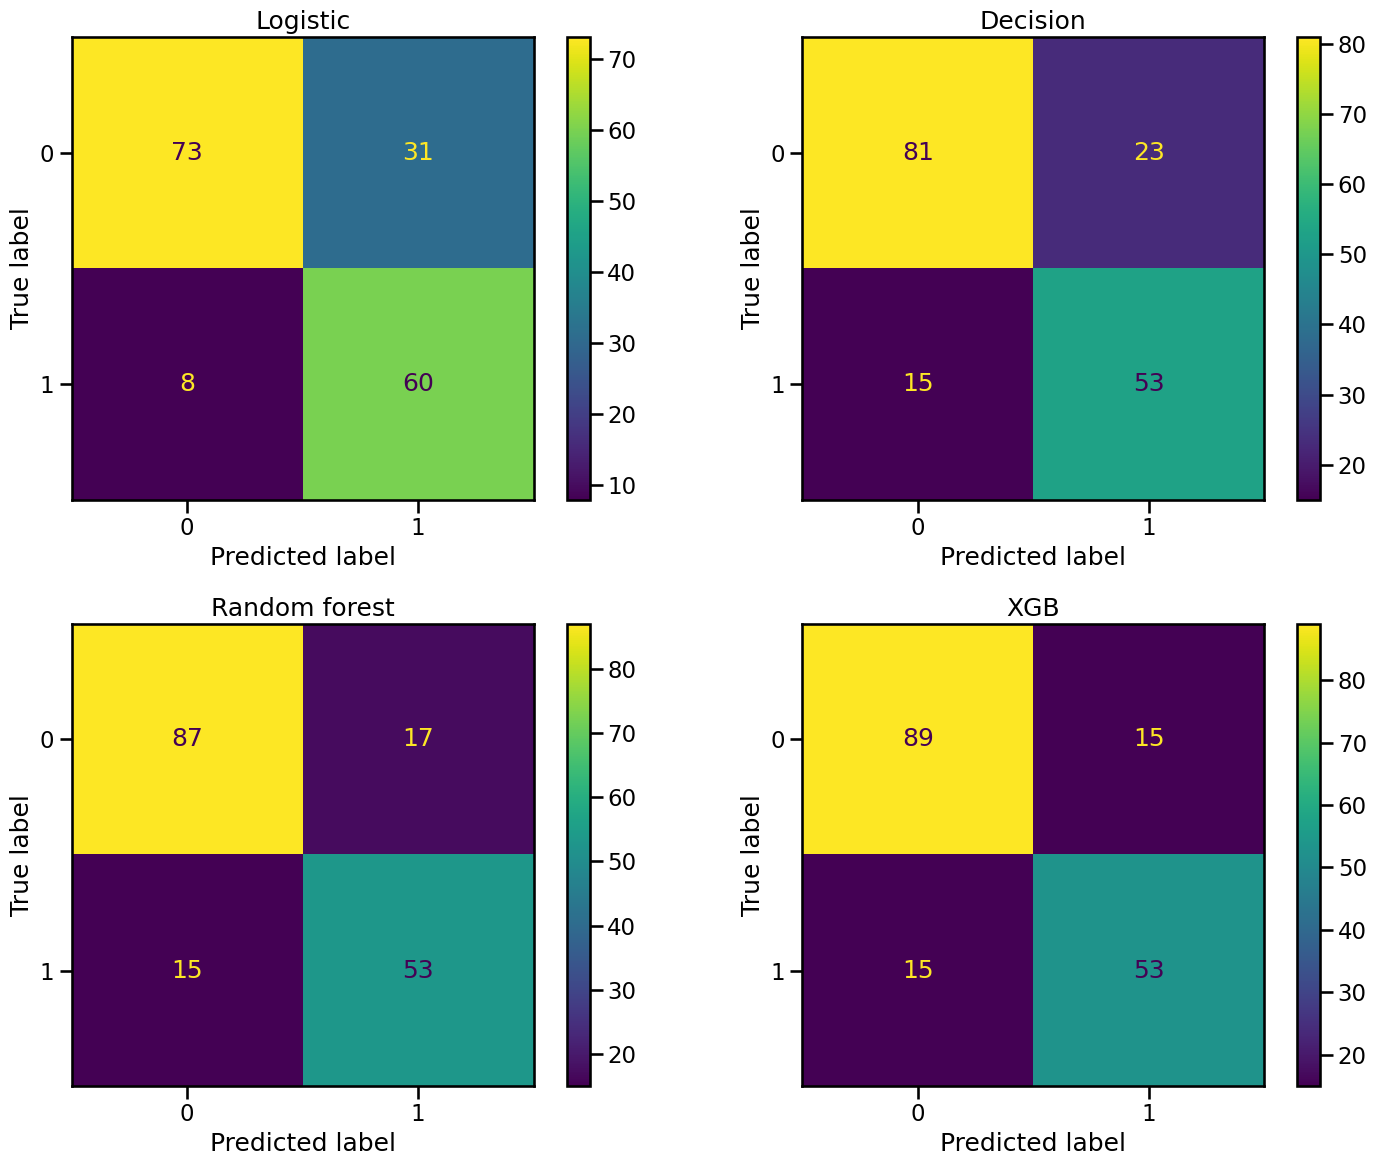

In [406]:
sns.set_context('talk')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=log_cf)
disp.plot(ax=axes[0, 0]) 
axes[0, 0].set_title("Logistic")

disp = ConfusionMatrixDisplay(confusion_matrix=dec_cf)
disp.plot(ax=axes[0, 1])
axes[0, 1].set_title("Decision")

disp = ConfusionMatrixDisplay(confusion_matrix=rf_cf)
disp.plot(ax=axes[1, 0])
axes[1, 0].set_title("Random forest")

disp = ConfusionMatrixDisplay(confusion_matrix=xgb_cf)
disp.plot(ax=axes[1, 1])
axes[1, 1].set_title("XGB")

plt.tight_layout() 
plt.show() #good

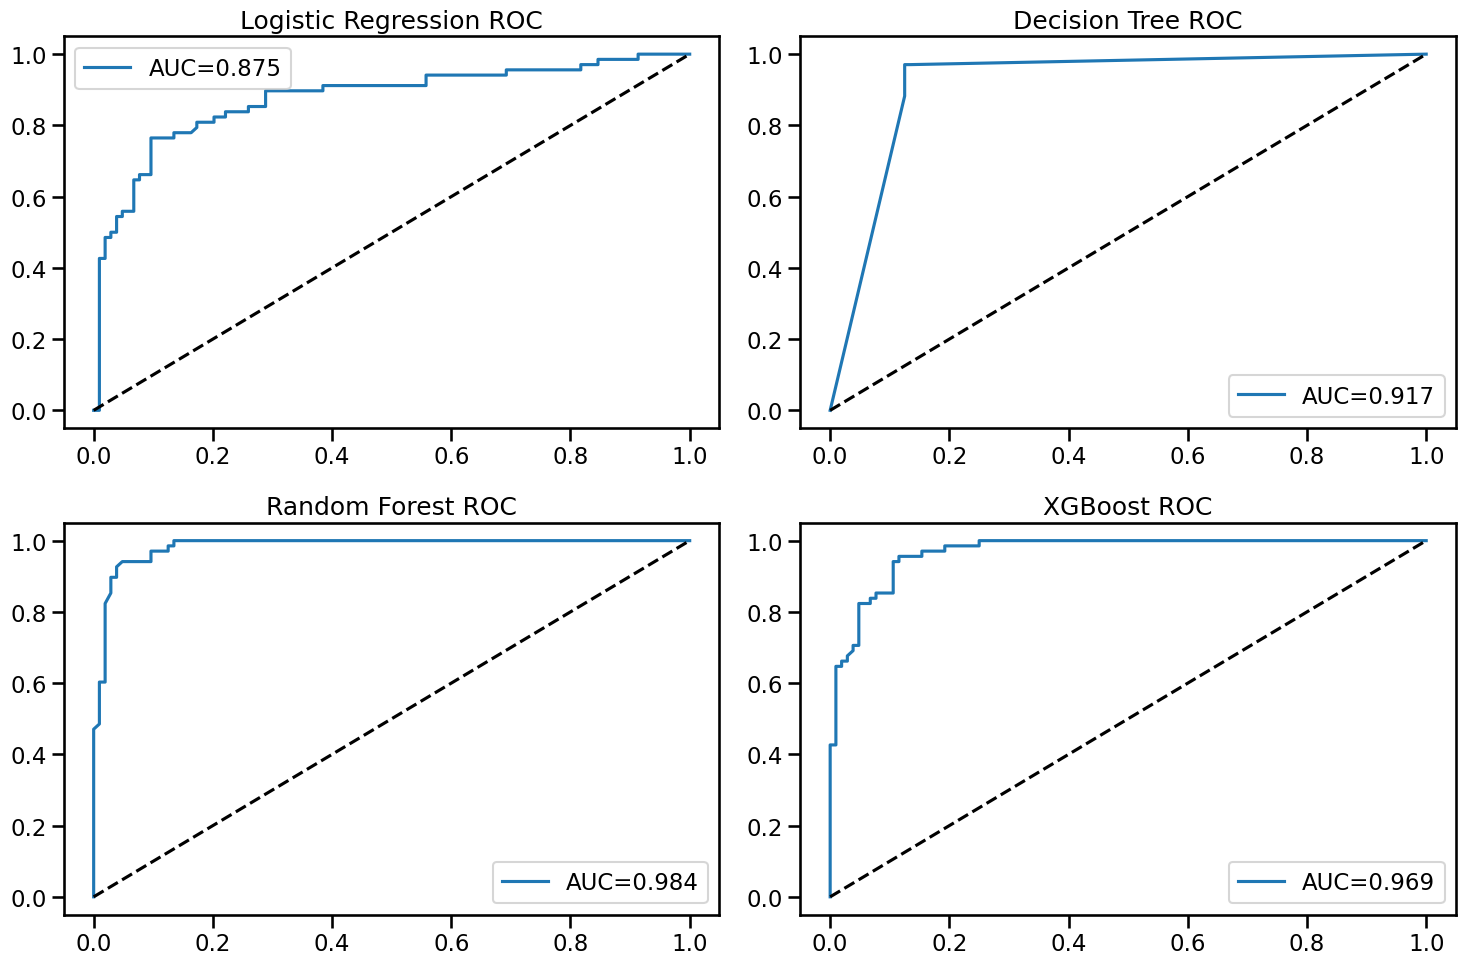

In [407]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
y_prob = model_log.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'AUC={auc(fpr, tpr):.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Logistic Regression ROC')
plt.legend()

plt.subplot(2, 2, 2)
y_prob = DTC.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'AUC={auc(fpr, tpr):.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Decision Tree ROC')
plt.legend()

plt.subplot(2, 2, 3)
y_prob = RFTC.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'AUC={auc(fpr, tpr):.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Random Forest ROC')
plt.legend()

plt.subplot(2, 2, 4)
y_prob = xgbc.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'AUC={auc(fpr, tpr):.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('XGBoost ROC')
plt.legend()

plt.tight_layout()
plt.show()

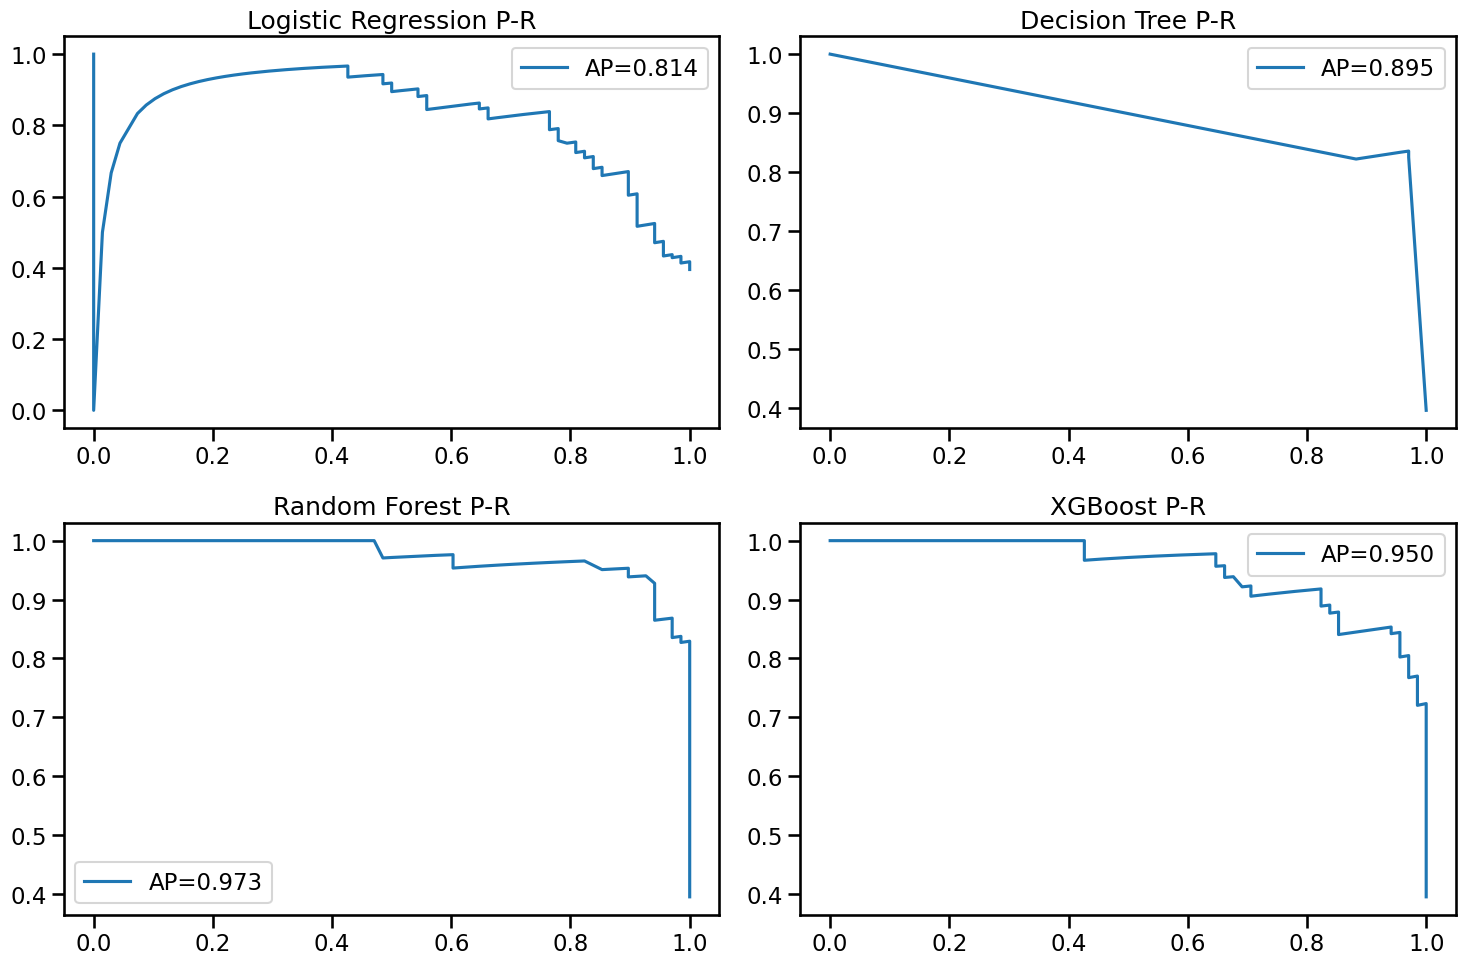

In [408]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
y_prob = model_log.predict_proba(X_test_scaled)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.plot(recall, precision, label=f'AP={auc(recall, precision):.3f}')
plt.title('Logistic Regression P-R')
plt.legend()

plt.subplot(2, 2, 2)
y_prob = DTC.predict_proba(X_test_scaled)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.plot(recall, precision, label=f'AP={auc(recall, precision):.3f}')
plt.title('Decision Tree P-R')
plt.legend()

plt.subplot(2, 2, 3)
y_prob = RFTC.predict_proba(X_test_scaled)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.plot(recall, precision, label=f'AP={auc(recall, precision):.3f}')
plt.title('Random Forest P-R')
plt.legend()

plt.subplot(2, 2, 4)
y_prob = xgbc.predict_proba(X_test_scaled)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.plot(recall, precision, label=f'AP={auc(recall, precision):.3f}')
plt.title('XGBoost P-R')
plt.legend()

plt.tight_layout()
plt.show()

In [409]:
#Conclusion
#XGBoost has the best accuracy while Random forest got the best roc, auc curves with xgboost being a close second

In [417]:
#Selected mode -> XGBoost
param_grid = {
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.005 ,0.02, 0.01, 0.1],
    'n_estimators': [100, 200, 400, 300 500]
}
grid_search = GridSearchCV(xgbc, param_grid, cv=5,  verbose=2, scoring='neg_mean_squared_error')
grid_search.fit(X_train_scaled, y_train)
best = grid_search.best_estimator_
y_pred = best.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)
print("XGBoost:")
print(f"Best depth: {grid_search.best_params_['max_depth']}")
print(f"Best learning rate: {grid_search.best_params_['learning_rate']}")
print(f"Best n_estimators: {grid_search.best_params_['n_estimators']}")
print(f"Test Accuracy: {test_accuracy}")
# XGBoost:
# Best depth: 6
# Best learning rate: 0.01
# Best n_estimators: 300
# Test Accuracy: 0.8197674418604651 These are the best paramaters

Fitting 5 folds for each of 80 candidates, totalling 400 fits
[CV] END .learning_rate=0.005, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END .learning_rate=0.005, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END .learning_rate=0.005, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END .learning_rate=0.005, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END .learning_rate=0.005, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END .learning_rate=0.005, max_depth=3, n_estimators=200; total time=   0.1s
[CV] END .learning_rate=0.005, max_depth=3, n_estimators=200; total time=   0.1s
[CV] END .learning_rate=0.005, max_depth=3, n_estimators=200; total time=   0.1s
[CV] END .learning_rate=0.005, max_depth=3, n_estimators=200; total time=   0.1s
[CV] END .learning_rate=0.005, max_depth=3, n_estimators=200; total time=   0.1s
[CV] END .learning_rate=0.005, max_depth=3, n_estimators=400; total time=   0.1s
[CV] END .learning_rate=0.005, max_depth=3, n_e